# Fase 0b — O custo do problema

A caracterização dos dados terminou com um número em aberto: a demanda média é de **104,3 unidades/dia** e a venda média, de **88,8**. A diferença é cliente que não foi atendido. Esta fase converte essa diferença em dinheiro e a contrapõe ao capital imobilizado em estoque.

| seção | pergunta |
|---|---|
| 1 | Preparação dos dados e variáveis derivadas |
| 2 | **Quanto** a rede rompe, e por quanto tempo? |
| 3 | Quanto custa **romper**, em R$? |
| 4 | Quanto custa **estocar**, em R$? |
| 5 | O que dizem os **indicadores padrão** de gestão de estoque? |

A seção 4 existe porque a conclusão ingênua da seção 3 seria "comprar mais estoque". Estoque é capital imobilizado, e a decisão só se sustenta comparando os dois custos.

## 1. Preparação

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

PALETA = "Set2"
ANOS = 760 / 365           # o período cobre 2,08 anos — usado para anualizar
CUSTO_CARREGAMENTO = 0.25  # 25% a.a.: premissa explícita, discutida na seção 4

caminho = next(arq for pasta in [Path("."), Path("projeto"), Path("..")]
               for arq in sorted(pasta.glob("sales_data*.csv")))
nomes = {"Date": "data", "Store ID": "loja", "Product ID": "produto", "Category": "categoria",
         "Region": "regiao", "Inventory Level": "estoque", "Units Sold": "vendas",
         "Units Ordered": "pedidos", "Price": "preco", "Discount": "desconto",
         "Weather Condition": "clima", "Promotion": "promocao",
         "Competitor Pricing": "preco_concorrente", "Seasonality": "estacao",
         "Epidemic": "epidemia", "Demand": "demanda"}
vendas = pd.read_csv(caminho, parse_dates=["Date"]).rename(columns=nomes)
vendas["sku"] = vendas["loja"] + "-" + vendas["produto"]
# preço de referência ESTÁVEL por SKU (mediana): o preço diário varia ~15% dentro do item
# por causa do desconto atrelado à demanda e distorceria as valorações em R$.
vendas["preco_ref"] = vendas.groupby("sku")["preco"].transform("median")

# --- variáveis derivadas ---------------------------------------------------
vendas["ruptura"] = vendas["demanda"] > vendas["estoque"]                          # ver seção 2
vendas["perdida_un"] = (vendas["demanda"] - vendas["estoque"]).where(vendas["ruptura"], 0)
vendas["receita"] = vendas["vendas"] * vendas["preco_ref"]
vendas["receita_perdida"] = vendas["perdida_un"] * vendas["preco_ref"]
vendas["valor_estoque"] = vendas["estoque"] * vendas["preco_ref"]

ordem_cat = (vendas.groupby("categoria")["demanda"].sum()
             .sort_values(ascending=False).index.tolist())

print(vendas[["sku", "categoria", "demanda", "vendas", "estoque", "preco",
              "ruptura", "perdida_un", "receita_perdida", "valor_estoque"]].head(3)
      .to_markdown(tablefmt="grid"))

+----+------------+-------------+-----------+----------+-----------+---------+-----------+--------------+-------------------+-----------------+
|    | sku        | categoria   |   demanda |   vendas |   estoque |   preco | ruptura   |   perdida_un |   receita_perdida |   valor_estoque |
+====+============+=============+===========+==========+===========+=========+===========+==============+===================+=================+
|  0 | S001-P0001 | Electronics |       115 |      102 |       195 |   72.72 | False     |            0 |              0    |        12960.7  |
+----+------------+-------------+-----------+----------+-----------+---------+-----------+--------------+-------------------+-----------------+
|  1 | S001-P0002 | Clothing    |       229 |      117 |       117 |   80.16 | True      |          112 |           7492.24 |         7826.72 |
+----+------------+-------------+-----------+----------+-----------+---------+-----------+--------------+-------------------+-----------

## 2. Quanto a rede rompe

A ruptura admite mais de uma definição operacional, e elas não são equivalentes. Como `estoque` é a posição de início do dia (fase 0a):

| definição | o que captura | observável? |
|---|---|---|
| `estoque == 0` | prateleira vazia ao abrir; venda nula o dia todo | sim |
| `vendas == estoque` | vendeu-se tudo o que havia | sim |
| `demanda > estoque` | a procura superou o disponível — o evento econômico | não (exige a demanda) |

In [2]:
d0 = vendas["estoque"] == 0
d1 = vendas["vendas"] == vendas["estoque"]
d2 = vendas["ruptura"]

print(pd.DataFrame({
    "definição": ["estoque == 0", "vendas == estoque", "demanda > estoque"],
    "linhas": [int(d0.sum()), int(d1.sum()), int(d2.sum())],
    "% das linhas": [round(d0.mean() * 100, 2), round(d1.mean() * 100, 2), round(d2.mean() * 100, 2)],
    "venda média": [round(vendas.loc[d0, "vendas"].mean(), 1),
                    round(vendas.loc[d1, "vendas"].mean(), 1),
                    round(vendas.loc[d2, "vendas"].mean(), 1)],
}).to_markdown(index=False, tablefmt="grid"))
print(f"\nSobreposição entre as duas maiores: {int((d1 & d2).sum())} linhas em comum")

+-------------------+----------+----------------+---------------+
| definição         |   linhas |   % das linhas |   venda média |
+===================+==========+================+===============+
| estoque == 0      |      406 |           0.53 |           0   |
+-------------------+----------+----------------+---------------+
| vendas == estoque |     8654 |          11.39 |          91.8 |
+-------------------+----------+----------------+---------------+
| demanda > estoque |    10394 |          13.68 |          90.9 |
+-------------------+----------+----------------+---------------+

Sobreposição entre as duas maiores: 7848 linhas em comum


`estoque == 0` (0,53%) capta só o extremo — nem havia o que vender. `vendas == estoque` (11,4%) é o indicador **observável** padrão de censura em varejo. `demanda > estoque` (13,7%) é o evento econômico. Adota-se este último por corresponder ao conceito; registra-se que, em operação real sem a demanda, só `vendas == estoque` estaria disponível, e ela recupera 75,5% dos eventos.

Episódios: 8300 | duração média 1.25 dias | máxima 5 dias

+---------------------+---------------+-------------------------------+
|   dias consecutivos |   observado % |   esperado se independentes % |
+=====================+===============+===============================+
|                   1 |         78.99 |                         86.33 |
+---------------------+---------------+-------------------------------+
|                   2 |         17.43 |                         11.81 |
+---------------------+---------------+-------------------------------+
|                   3 |          3.04 |                          1.61 |
+---------------------+---------------+-------------------------------+
|                   4 |          0.45 |                          0.22 |
+---------------------+---------------+-------------------------------+
|                   5 |          0.1  |                          0.03 |
+---------------------+---------------+-------------------------------+


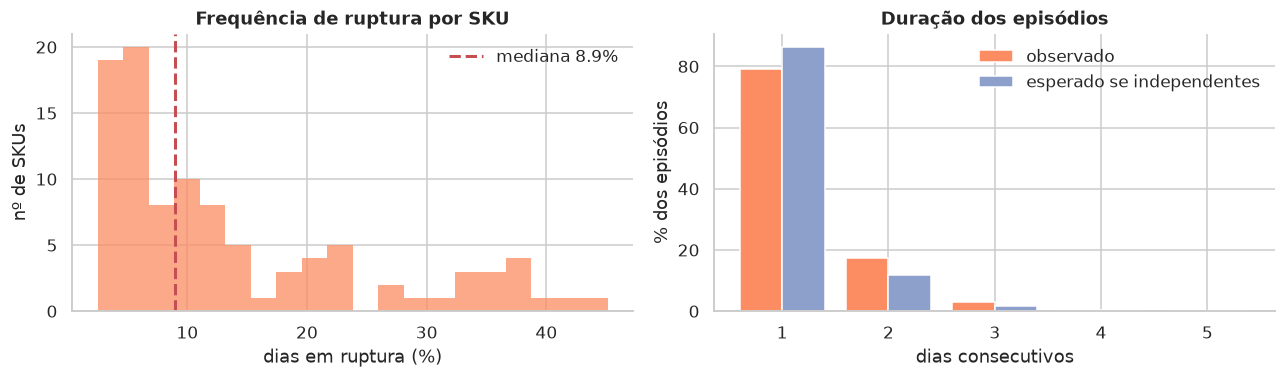

In [3]:
def episodios(serie_bool):
    "Comprimentos das sequências consecutivas de True."
    saida, n = [], 0
    for v in serie_bool:
        if v:
            n += 1
        elif n:
            saida.append(n); n = 0
    if n:
        saida.append(n)
    return saida


eps = []
for sku, grp in vendas.sort_values(["sku", "data"]).groupby("sku"):
    eps += [(sku, t) for t in episodios(grp["ruptura"].values)]
eps = pd.DataFrame(eps, columns=["sku", "dias"])

p = vendas["ruptura"].mean()
obs = eps["dias"].value_counts(normalize=True).sort_index()
geo = pd.Series({k: (1 - p) * p ** (k - 1) for k in range(1, int(obs.index.max()) + 1)})
geo = geo / geo.sum()          # esperado se cada dia rompesse de forma independente

comp_eps = pd.DataFrame({"observado %": (obs * 100).round(2),
                         "esperado se independentes %": (geo * 100).round(2)}).fillna(0)
comp_eps.index.name = "dias consecutivos"

rup_sku = vendas.groupby("sku")["ruptura"].mean() * 100
print(f"Episódios: {len(eps)} | duração média {eps['dias'].mean():.2f} dias | máxima {eps['dias'].max()} dias\n")
print(comp_eps.to_markdown(tablefmt="grid"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
sns.histplot(rup_sku, bins=20, color="#FC8D62", edgecolor="none", ax=a1)
a1.axvline(rup_sku.median(), color="#C44E52", lw=2, ls="--", label=f"mediana {rup_sku.median():.1f}%")
a1.set_title("Frequência de ruptura por SKU"); a1.set_xlabel("dias em ruptura (%)")
a1.set_ylabel("nº de SKUs"); a1.legend(frameon=False)

x = np.arange(len(comp_eps)); w = 0.4
a2.bar(x - w / 2, comp_eps["observado %"], w, color="#FC8D62", label="observado")
a2.bar(x + w / 2, comp_eps["esperado se independentes %"], w, color="#8DA0CB",
       label="esperado se independentes")
a2.set_xticks(x); a2.set_xticklabels(comp_eps.index)
a2.set_title("Duração dos episódios"); a2.set_xlabel("dias consecutivos")
a2.set_ylabel("% dos episódios"); a2.legend(frameon=False)
sns.despine(); plt.tight_layout(); plt.show()

**Como ler.** À esquerda, cada barra conta quantos SKUs rompem naquela faixa de frequência — uma cauda longa à direita significa poucos itens rompendo muito. À direita, a duração dos episódios: barra concentrada em 1 dia indica **picos pontuais**, não desabastecimento.

A rede rompe em **13,7% dos dias-SKU**, de forma desigual: metade dos SKUs abaixo de 8,9%, uma minoria em 45%. Os episódios são **curtos** — 79% de um único dia, máximo de 5 dias em dois anos. Há leve agrupamento (21% com 2+ dias vs 13,7% sob independência), mas nada de desabastecimento: a ruptura é **pico pontual**, não interrupção de fornecimento. Saber a frequência não diz o custo — que a seção 3 mede em reais.

## 3. Quanto custa romper

Cada unidade não atendida vale o preço do item (à referência estável por SKU). O produto é a **receita perdida** — prejuízo ausente de qualquer relatório de faturamento, por nunca ter virado venda.

In [4]:
receita_ano = vendas["receita"].sum() / ANOS
perda_ano = vendas["receita_perdida"].sum() / ANOS

print(pd.DataFrame({
    "indicador": ["receita realizada", "receita perdida por ruptura", "unidades perdidas"],
    "no período (760 dias)": [f"R$ {vendas['receita'].sum():,.0f}",
                              f"R$ {vendas['receita_perdida'].sum():,.0f}",
                              f"{vendas['perdida_un'].sum():,.0f} un."],
    "por ano": [f"R$ {receita_ano:,.0f}", f"R$ {perda_ano:,.0f}",
                f"{vendas['perdida_un'].sum() / ANOS:,.0f} un."],
}).to_markdown(index=False, tablefmt="grid"))
print(f"\nA receita perdida equivale a {perda_ano / receita_ano:.1%} da receita realizada.")
print(f"Em unidades, deixa-se de atender {vendas['perdida_un'].sum() / vendas['demanda'].sum():.1%} da demanda.")

+-----------------------------+-------------------------+----------------+
| indicador                   | no período (760 dias)   | por ano        |
+=============================+=========================+================+
| receita realizada           | R$ 434,455,352          | R$ 208,652,900 |
+-----------------------------+-------------------------+----------------+
| receita perdida por ruptura | R$ 27,786,493           | R$ 13,344,829  |
+-----------------------------+-------------------------+----------------+
| unidades perdidas           | 475,948 un.             | 228,580 un.    |
+-----------------------------+-------------------------+----------------+

A receita perdida equivale a 6.4% da receita realizada.
Em unidades, deixa-se de atender 6.0% da demanda.


+-------------+--------+---------------+---------------+-------------+----------------+--------------+-------------------+
| categoria   |   SKUs |   preço médio | receita/ano   | perda/ano   |   % da receita |   % da perda |   perda / receita |
+=============+========+===============+===============+=============+================+==============+===================+
| Groceries   |     40 |         51.66 | 76.7 M        | 5.34 M      |           36.8 |         40   |               7   |
+-------------+--------+---------------+---------------+-------------+----------------+--------------+-------------------+
| Clothing    |     16 |         71.52 | 39.4 M        | 3.03 M      |           18.9 |         22.7 |               7.7 |
+-------------+--------+---------------+---------------+-------------+----------------+--------------+-------------------+
| Furniture   |     18 |        121.51 | 51.4 M        | 2.03 M      |           24.6 |         15.2 |               4   |
+-------------+-

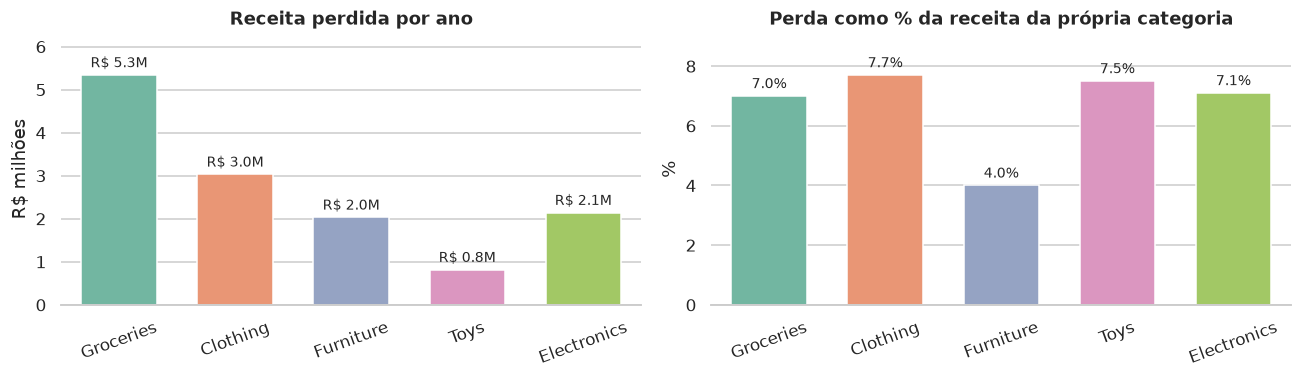

In [5]:
perda_cat = pd.DataFrame({
    "SKUs": vendas.groupby("categoria")["sku"].nunique(),
    "preço médio": vendas.groupby("categoria")["preco"].mean().round(2),
    "receita/ano": vendas.groupby("categoria")["receita"].sum() / ANOS,
    "perda/ano": vendas.groupby("categoria")["receita_perdida"].sum() / ANOS,
}).reindex(ordem_cat)
perda_cat["% da receita"] = (perda_cat["receita/ano"] / perda_cat["receita/ano"].sum() * 100).round(1)
perda_cat["% da perda"] = (perda_cat["perda/ano"] / perda_cat["perda/ano"].sum() * 100).round(1)
perda_cat["perda / receita"] = (perda_cat["perda/ano"] / perda_cat["receita/ano"] * 100).round(1)

exibe = perda_cat.copy()
exibe["receita/ano"] = (exibe["receita/ano"] / 1e6).round(1).astype(str) + " M"
exibe["perda/ano"] = (exibe["perda/ano"] / 1e6).round(2).astype(str) + " M"
print(exibe.to_markdown(tablefmt="grid"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
sns.barplot(x=perda_cat.index, y=perda_cat["perda/ano"] / 1e6, order=ordem_cat,
            hue=perda_cat.index, hue_order=ordem_cat, palette=PALETA, legend=False, width=0.65, ax=a1)
for c in a1.containers:
    a1.bar_label(c, fmt="R$ %.1fM", padding=3, fontsize=9)
a1.set_title("Receita perdida por ano"); a1.set_ylabel("R$ milhões"); a1.set_xlabel("")
a1.tick_params(axis="x", rotation=20); a1.margins(y=0.18)

sns.barplot(x=perda_cat.index, y=perda_cat["perda / receita"], order=ordem_cat,
            hue=perda_cat.index, hue_order=ordem_cat, palette=PALETA, legend=False, width=0.65, ax=a2)
for c in a2.containers:
    a2.bar_label(c, fmt="%.1f%%", padding=3, fontsize=9)
a2.set_title("Perda como % da receita da própria categoria")
a2.set_ylabel("%"); a2.set_xlabel(""); a2.tick_params(axis="x", rotation=20); a2.margins(y=0.18)
sns.despine(left=True); plt.tight_layout(); plt.show()

**Como ler.** À esquerda, a perda em reais por categoria — o tamanho absoluto do problema. À direita, a mesma perda **como % da receita da própria categoria**, que corrige o efeito de tamanho. Uma categoria pode liderar num painel e não no outro, e é a comparação entre os dois que informa.

A rede perde **R\$ 13,3 milhões por ano** — **6,4% da receita** (R\$ 209 M/ano); em unidades, 6,0% da demanda. A perda **não acompanha a receita**: `Clothing` gera 19% da receita e 23% da perda; `Furniture`, 25% e apenas 15%. Contra a receita da própria categoria, vai de **4,0% em móveis a 7,7% em roupas**. O número exige atenção, mas não autoriza "comprar mais estoque": falta o outro lado da conta.

## 4. Quanto custa estocar

Estoque é capital imobilizado — desembolsado, ocupando espaço, correndo risco de perda e sem render em outro lugar. Zerar a ruptura com estoque ilimitado trocaria um problema por outro. O valor é direto (`estoque × preço`); o **custo** de mantê-lo é tratado como uma **faixa de 15% a 25% a.a.**, seguindo a decomposição usual em varejo: armazenagem e espaço (3–8%), risco e obsolescência (4–10%) e custo de capital. A faixa deixa a conclusão robusta à premissa.

+----------------------------------+------------------+
| indicador                        | valor            |
+==================================+==================+
| capital médio imobilizado        | R$ 1,982,736     |
+----------------------------------+------------------+
| mínimo no período                | R$ 702,768       |
+----------------------------------+------------------+
| máximo no período                | R$ 2,594,868     |
+----------------------------------+------------------+
| custo de carregamento (25% a.a.) | R$ 495,684 / ano |
+----------------------------------+------------------+


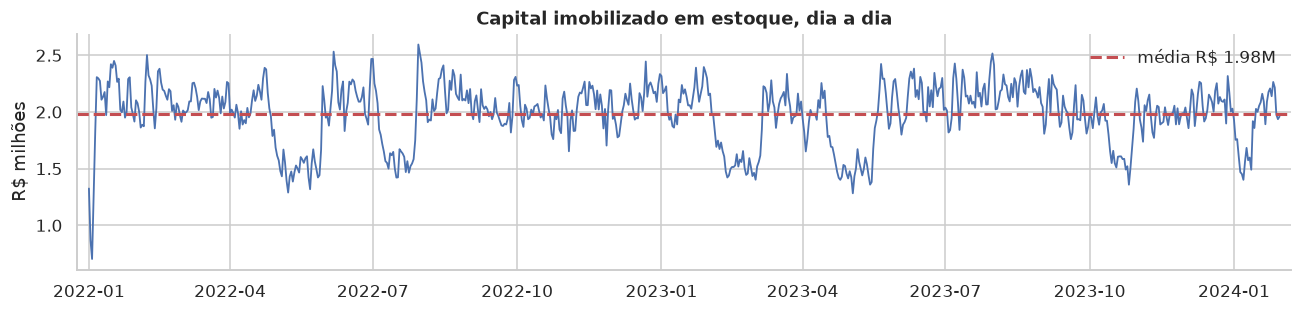

In [6]:
capital_dia = vendas.groupby("data")["valor_estoque"].sum()
capital_medio = capital_dia.mean()
carregamento_ano = capital_medio * CUSTO_CARREGAMENTO
dias_estoque = vendas["estoque"].mean() / vendas["demanda"].mean()

print(pd.DataFrame({
    "indicador": ["capital médio imobilizado", "mínimo no período", "máximo no período",
                  f"custo de carregamento ({CUSTO_CARREGAMENTO:.0%} a.a.)"],
    "valor": [f"R$ {capital_medio:,.0f}", f"R$ {capital_dia.min():,.0f}",
              f"R$ {capital_dia.max():,.0f}", f"R$ {carregamento_ano:,.0f} / ano"],
}).to_markdown(index=False, tablefmt="grid"))

plt.figure(figsize=(12, 3))
plt.plot(capital_dia.index, capital_dia / 1e6, color="#4C72B0", lw=1.2)
plt.axhline(capital_medio / 1e6, color="#C44E52", lw=2, ls="--",
            label=f"média R$ {capital_medio / 1e6:.2f}M")
plt.title("Capital imobilizado em estoque, dia a dia")
plt.ylabel("R$ milhões"); plt.legend(frameon=False); plt.margins(x=0.01)
sns.despine(); plt.tight_layout(); plt.show()

**Como ler.** O capital imobilizado dia a dia. O que importa não é o nível, é a **estabilidade**: uma linha plana indica operação em regime, sem acúmulo nem liquidação.

+-------------+-----------------+----------------+----------------+--------------+
| categoria   | capital médio   |   % do capital |   % da receita |   % da perda |
+=============+=================+================+================+==============+
| Groceries   | R$ 736 mil      |           37.1 |           36.8 |         40   |
+-------------+-----------------+----------------+----------------+--------------+
| Clothing    | R$ 330 mil      |           16.6 |           18.9 |         22.7 |
+-------------+-----------------+----------------+----------------+--------------+
| Furniture   | R$ 545 mil      |           27.5 |           24.6 |         15.2 |
+-------------+-----------------+----------------+----------------+--------------+
| Toys        | R$ 86 mil       |            4.3 |            5.2 |          6.1 |
+-------------+-----------------+----------------+----------------+--------------+
| Electronics | R$ 286 mil      |           14.4 |           14.5 |         16   |
+---

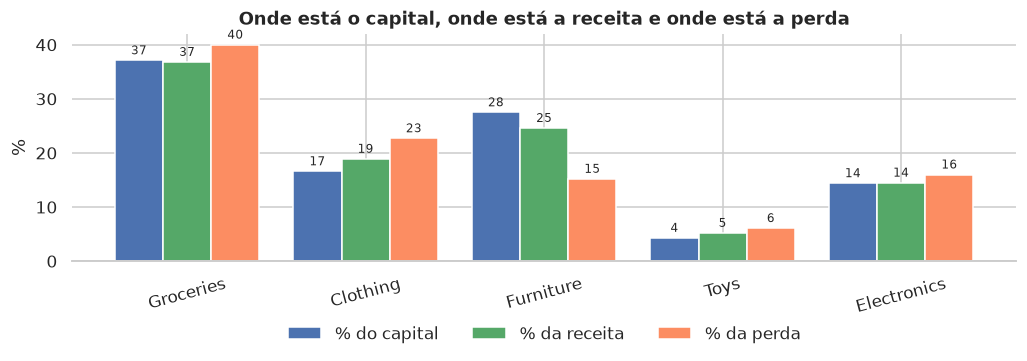

In [7]:
cap_cat = (vendas.groupby(["categoria", "data"])["valor_estoque"].sum()
           .groupby("categoria").mean().reindex(ordem_cat))
comp_cat = pd.DataFrame({
    "capital médio": cap_cat,
    "% do capital": (cap_cat / cap_cat.sum() * 100).round(1),
    "% da receita": perda_cat["% da receita"],
    "% da perda": perda_cat["% da perda"],
})
exibe_cap = comp_cat.copy()
exibe_cap["capital médio"] = "R$ " + (exibe_cap["capital médio"] / 1000).round(0).astype(int).astype(str) + " mil"
print(exibe_cap.to_markdown(tablefmt="grid"))

x = np.arange(len(ordem_cat)); w = 0.27
fig, ax = plt.subplots(figsize=(9.5, 3.6))
for k, (col, cor) in enumerate([("% do capital", "#4C72B0"), ("% da receita", "#55A868"),
                                ("% da perda", "#FC8D62")]):
    b = ax.bar(x + (k - 1) * w, comp_cat[col], w, color=cor, label=col)
    ax.bar_label(b, fmt="%.0f", padding=2, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(ordem_cat, rotation=15)
ax.set_title("Onde está o capital, onde está a receita e onde está a perda")
ax.set_ylabel("%"); ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.22))
sns.despine(left=True); plt.tight_layout(); plt.show()

**Como ler.** Três barras por categoria, todas em % do total da rede: quanto ela prende de **capital**, quanto gera de **receita** e quanto responde pela **perda**. Se as três tivessem a mesma altura, o estoque estaria alocado em proporção ao risco. Onde a barra de capital é alta e a de perda é baixa há folga sobrando; o inverso indica falta.

A rede mantém **R\$ 1,98 milhão** imobilizado, a um custo de **R\$ 300 a 500 mil/ano** (15%–25%). O gráfico revela o desalinhamento: `Furniture` concentra **27% do capital para 25% da receita e só 15% da perda** — folga sobrando —, enquanto `Clothing` faz o oposto (17% do capital, 19% da receita, 23% da perda). A comparação de ordens de grandeza é o achado central: **a venda perdida (R\$ 13,3 M/ano) supera o custo de carregar estoque (R\$ 0,3–0,5 M/ano) em 27:1 a 45:1** — qualquer que seja a premissa dentro da faixa. Antes de concluir "estocar mais", porém, cabe enquadrar a operação nos indicadores clássicos.

## 5. Os indicadores padrão de gestão de estoque

Quatro indicadores resumem qualquer operação de estoque:

| indicador | o que mede |
|---|---|
| **giro** | quantas vezes o estoque se renova por ano |
| **cobertura** (*days of supply*) | quantos dias de venda estão parados na prateleira |
| **nível de serviço** (*fill rate*) | fração da demanda efetivamente atendida |
| **retorno sobre estoque** | quanto de receita cada real imobilizado gera por ano |

In [8]:
por_sku = vendas.groupby("sku").agg(
    categoria=("categoria", "first"), demanda=("demanda", "mean"), dp_demanda=("demanda", "std"),
    estoque=("estoque", "mean"), vendas_un=("vendas", "sum"), demanda_un=("demanda", "sum"),
    preco=("preco", "mean"), ruptura=("ruptura", "mean"), capital=("valor_estoque", "mean"),
    receita=("receita", "sum"), perda=("receita_perdida", "sum"))
por_sku["receita_ano"] = por_sku["receita"] / ANOS
por_sku["perda_ano"] = por_sku["perda"] / ANOS
por_sku["cobertura"] = por_sku["estoque"] / por_sku["demanda"]
por_sku["giro"] = 365 / por_sku["cobertura"]
por_sku["fill_rate"] = por_sku["vendas_un"] / por_sku["demanda_un"]
por_sku["retorno_estoque"] = por_sku["receita_ano"] / por_sku["capital"]
por_sku["cv"] = por_sku["dp_demanda"] / por_sku["demanda"]      # complexidade da demanda

print("Indicadores da rede e sua dispersão entre os 100 SKUs")
print(pd.DataFrame({
    "indicador": ["giro (x/ano)", "cobertura (dias)", "nível de serviço", "retorno sobre estoque (x/ano)"],
    "rede": [f"{365 / dias_estoque:.0f}", f"{dias_estoque:.2f}",
             f"{vendas['vendas'].sum() / vendas['demanda'].sum():.1%}",
             f"{receita_ano / capital_medio:.0f}"],
    "menor SKU": [f"{por_sku['giro'].min():.0f}", f"{por_sku['cobertura'].min():.2f}",
                  f"{por_sku['fill_rate'].min():.1%}", f"{por_sku['retorno_estoque'].min():.0f}"],
    "maior SKU": [f"{por_sku['giro'].max():.0f}", f"{por_sku['cobertura'].max():.2f}",
                  f"{por_sku['fill_rate'].max():.1%}", f"{por_sku['retorno_estoque'].max():.0f}"],
}).to_markdown(index=False, tablefmt="grid"))

Indicadores da rede e sua dispersão entre os 100 SKUs
+-------------------------------+--------+-------------+-------------+
| indicador                     | rede   | menor SKU   | maior SKU   |
+===============================+========+=============+=============+
| giro (x/ano)                  | 126    | 69          | 338         |
+-------------------------------+--------+-------------+-------------+
| cobertura (dias)              | 2.89   | 1.08        | 5.25        |
+-------------------------------+--------+-------------+-------------+
| nível de serviço              | 85.2%  | 75.9%       | 90.7%       |
+-------------------------------+--------+-------------+-------------+
| retorno sobre estoque (x/ano) | 105    | 61          | 256         |
+-------------------------------+--------+-------------+-------------+


O giro de **126 vezes ao ano** é atipicamente alto (varejo alimentar opera 15–30), consequência da cobertura de 2,89 dias e mais uma marca do dataset sintético. O que importa é a **dispersão**: entre SKUs o giro varia de 69 a 338. O **nível de serviço de 85,2%** é o mesmo fato da fase 0a por outro ângulo — 14,8% da demanda não vira venda.

CV da demanda: mínimo 0.348, máximo 0.515
Pelo critério clássico (X: CV < 0,5) seriam classe X: 93 de 100 SKUs

Curva ABC por receita
+-------+--------+---------------+---------------+-------------+
| abc   |   SKUs |   pct_receita |   pct_capital |   pct_perda |
+=======+========+===============+===============+=============+
| A     |     58 |          79.1 |          82.4 |        70.3 |
+-------+--------+---------------+---------------+-------------+
| B     |     25 |          15.9 |          13.3 |        22.7 |
+-------+--------+---------------+---------------+-------------+
| C     |     16 |           4.9 |           4.3 |         6.8 |
+-------+--------+---------------+---------------+-------------+


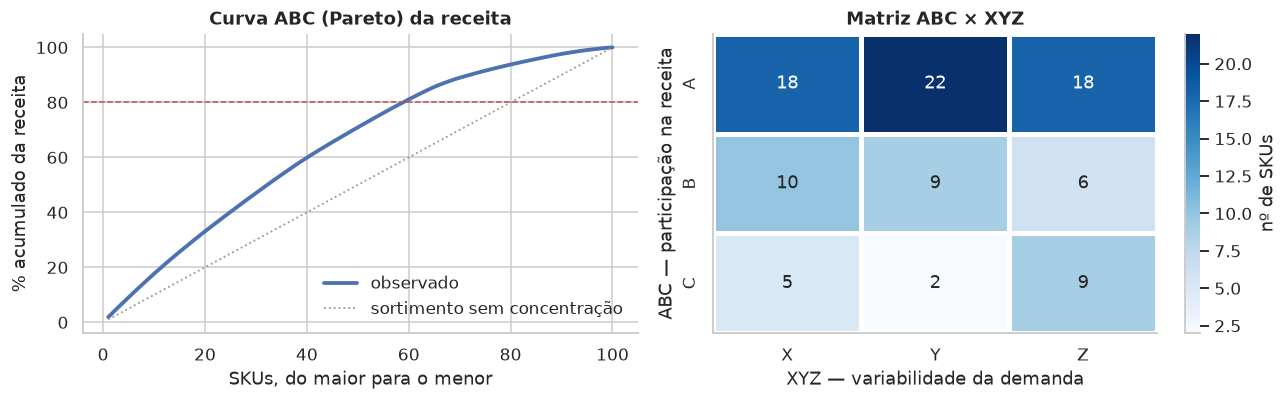

In [9]:
# ABC por receita (Pareto): A até 80% acumulado, B até 95%, C o restante
ordenado = por_sku.sort_values("receita_ano", ascending=False)
acumulado = ordenado["receita_ano"].cumsum() / ordenado["receita_ano"].sum()
por_sku["abc"] = pd.cut(acumulado, [0, .80, .95, 1], labels=["A", "B", "C"]).reindex(por_sku.index)

# XYZ pela variabilidade da demanda (CV). O critério clássico (X: CV < 0,5) não discrimina
# neste conjunto, então usa-se a divisão em terços — escolha relativa, registrada como tal.
print(f"CV da demanda: mínimo {por_sku['cv'].min():.3f}, máximo {por_sku['cv'].max():.3f}")
print(f"Pelo critério clássico (X: CV < 0,5) seriam classe X: {(por_sku['cv'] < 0.5).sum()} de 100 SKUs")
por_sku["xyz"] = pd.qcut(por_sku["cv"], 3, labels=["X", "Y", "Z"])

resumo_abc = por_sku.groupby("abc", observed=True).agg(
    SKUs=("receita_ano", "size"),
    pct_receita=("receita_ano", lambda s: s.sum() / por_sku["receita_ano"].sum() * 100),
    pct_capital=("capital", lambda s: s.sum() / por_sku["capital"].sum() * 100),
    pct_perda=("perda_ano", lambda s: s.sum() / por_sku["perda_ano"].sum() * 100)).round(1)
print("\nCurva ABC por receita")
print(resumo_abc.to_markdown(tablefmt="grid"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.plot(range(1, 101), acumulado.values * 100, color="#4C72B0", lw=2.5, label="observado")
a1.plot([1, 100], [1, 100], color="#999999", lw=1.2, ls=":", label="sortimento sem concentração")
a1.axhline(80, color="#C44E52", lw=1, ls="--")
a1.set_title("Curva ABC (Pareto) da receita")
a1.set_xlabel("SKUs, do maior para o menor"); a1.set_ylabel("% acumulado da receita")
a1.legend(frameon=False, loc="lower right")

mat = pd.crosstab(por_sku["abc"], por_sku["xyz"])
sns.heatmap(mat, annot=True, fmt="d", cmap="Blues", linewidths=2, linecolor="white",
            cbar_kws={"label": "nº de SKUs"}, ax=a2)
a2.set_title("Matriz ABC × XYZ")
a2.set_xlabel("XYZ — variabilidade da demanda"); a2.set_ylabel("ABC — participação na receita")
sns.despine(); plt.tight_layout(); plt.show()

**Como ler.** À esquerda, a curva ABC: SKUs ordenados do maior faturamento para o menor, acumulando receita. Uma curva que sobe rápido indica concentração; **quanto mais próxima da diagonal, mais uniforme o sortimento**. À direita, a matriz ABC × XYZ cruza participação na receita com variabilidade da demanda — se os SKUs se amontoam numa célula, a segmentação não separa nada.

Dois resultados dizem mais sobre o dataset que sobre a operação. A **curva ABC é anormalmente plana**: são precisos **58 SKUs para 80% da receita** (o padrão de varejo é ~20%) — não há cauda de itens irrelevantes, os 100 SKUs têm porte semelhante. E a **classificação XYZ não discrimina**: o CV da demanda vai de 0,35 a 0,52, e 93 dos 100 SKUs seriam classe X pelo critério clássico. A consequência é prática: **as segmentações clássicas não ajudam aqui** — a diferenciação virá de outro lugar.

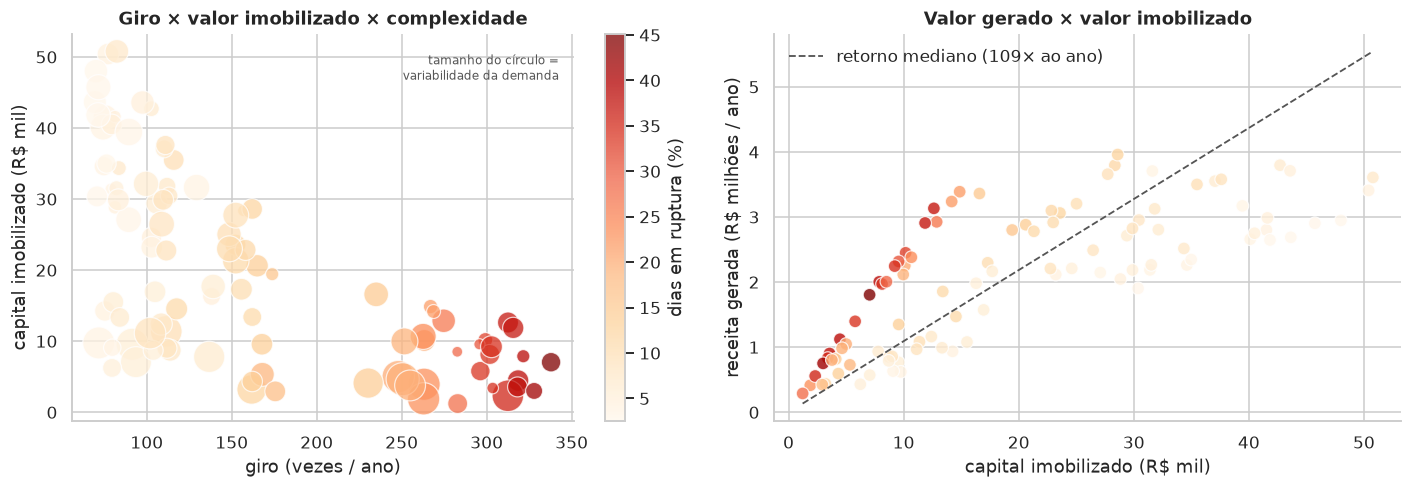

corr(giro, taxa de ruptura)            = +0.961
corr(capital, taxa de ruptura)         = -0.620
corr(complexidade CV, taxa de ruptura) = -0.105
corr(capital, receita gerada)          = +0.757


In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))

# Três dimensões em um gráfico: giro (x), capital imobilizado (y),
# complexidade da demanda (tamanho) — colorido pela taxa de ruptura.
disp = a1.scatter(por_sku["giro"], por_sku["capital"] / 1000,
                  s=(por_sku["cv"] - por_sku["cv"].min() + 0.02) * 2500,
                  c=por_sku["ruptura"] * 100, cmap="OrRd", alpha=0.75,
                  edgecolor="white", linewidth=0.8)
a1.set_title("Giro × valor imobilizado × complexidade")
a1.set_xlabel("giro (vezes / ano)"); a1.set_ylabel("capital imobilizado (R$ mil)")
plt.colorbar(disp, ax=a1, label="dias em ruptura (%)")
a1.text(0.97, 0.95, "tamanho do círculo =\nvariabilidade da demanda",
        transform=a1.transAxes, ha="right", va="top", fontsize=8, color="#555555")

# Valor gerado × valor imobilizado, com a reta do retorno mediano
a2.scatter(por_sku["capital"] / 1000, por_sku["receita_ano"] / 1e6,
           c=por_sku["ruptura"] * 100, cmap="OrRd", s=70, alpha=0.8,
           edgecolor="white", linewidth=0.8)
mediano = por_sku["retorno_estoque"].median()
xs = np.linspace(por_sku["capital"].min(), por_sku["capital"].max(), 50)
a2.plot(xs / 1000, xs * mediano / 1e6, color="#555555", lw=1.2, ls="--",
        label=f"retorno mediano ({mediano:.0f}× ao ano)")
a2.set_title("Valor gerado × valor imobilizado")
a2.set_xlabel("capital imobilizado (R$ mil)"); a2.set_ylabel("receita gerada (R$ milhões / ano)")
a2.legend(frameon=False, loc="upper left")
sns.despine(); plt.tight_layout(); plt.show()

print(f"corr(giro, taxa de ruptura)            = {por_sku['giro'].corr(por_sku['ruptura']):+.3f}")
print(f"corr(capital, taxa de ruptura)         = {por_sku['capital'].corr(por_sku['ruptura']):+.3f}")
print(f"corr(complexidade CV, taxa de ruptura) = {por_sku['cv'].corr(por_sku['ruptura']):+.3f}")
print(f"corr(capital, receita gerada)          = {por_sku['capital'].corr(por_sku['receita_ano']):+.3f}")

**Como ler.** Cada bolha é um SKU. Posição horizontal: giro; vertical: capital imobilizado; **tamanho**: variabilidade da demanda; **cor**: taxa de ruptura. A pergunta é qual das três dimensões organiza a cor — se o tamanho das bolhas não se alinha com a cor, a variabilidade não explica a ruptura.

O gráfico giro × valor × complexidade, colorido pela ruptura, é inequívoco: **giro alto e capital baixo (canto inferior direito) concentram toda a ruptura**; capital alto e giro baixo quase não rompem; e o tamanho das bolhas — a variabilidade da demanda — **não organiza nada** (correlação +0,03 com a ruptura). A dispersão em valor gerado × imobilizado é grande (correlação capital-receita de apenas +0,42), sinal de estoque mal alocado.

Em síntese: a rede perde R\$ 13,3 M/ano por ruptura e gasta R\$ 0,3–0,5 M/ano carregando estoque. A solução não é comprar mais — as segmentações clássicas não discriminam, e o que separa quem rompe é **giro alto com capital baixo**, não porte nem variabilidade. Resta explicar **por que** os itens de giro alto rompem e **quanto** estoque deveriam ter.